<a href="https://colab.research.google.com/github/xDanilog27/Bussiness-Inteligent/blob/main/Reto_Challenge_5_An%C3%A1lisis_de_Sentimientos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

De acuerdo con los reportes anuales publicados por la Asociación Nacional de Exportadores (ANALDEX) entre los años 2020-2024, llevar a cabo un análisis de sentimientos de riesgo.  Para este proceso es importante tener en cuenta las siguientes recomendaciones:

•	En un archivo de Excel, llevar a cabo un informe de análisis por cada uno de los años que arroja el análisis de sentimientos para los informes anuales.
•	En una hoja de Excel, crear dos gráficos (Histograma de Frecuencias, Spider Plot) en donde se consolide la información, con el fin de contrastar la evolución de los informes exportadores.
•	Crear un archivo de Excel con la información del análisis de sentimientos en donde se muestren las siguientes columnas:

*   Columna con las frases de análisis.
*   La polaridad alcanzada por cada frase (compound).
*   El sentimiento alcanzado por cada una de las frases.
*   El año de cada una de las frases.







0. Se procede con la instalación de los paquetes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk #Natural Laguage toolkit
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('punkt_tab') #Para hacer el proceso más eficiente

from google.colab import drive
drive.mount('/content/drive')



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Mounted at /content/drive


1. Se procede con la instalación de las librerias de análisis

In [ ]:
!pip install vaderSentiment #Diccionario de trabajo
!pip install -U spacy #Es otro diccionario updated
!pip  install download es_core_news_lg #Diccionario de trabajo en español
!pip install download es_core_ewb_sm #Diccionario en ingles
!pip install translate #Traducción automatica
!pip install wordcloud #Gráficos de nube de palabras
!python -m spacy download es_core_news_lg

# Librerias de Trabajo

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import spacy
from translate import Translator
from wordcloud import wordcloud

  Using cached download-0.3.5-py3-none-any.whl.metadata (3.8 kB)
ERROR: Could not find a version that satisfies the requirement es_core_news_lg (from versions: none)
ERROR: No matching distribution found for es_core_news_lg
  Using cached download-0.3.5-py3-none-any.whl.metadata (3.8 kB)
ERROR: Could not find a version that satisfies the requirement es_core_ewb_sm (from versions: none)
ERROR: No matching distribution found for es_core_ewb_sm


In [10]:
import nltk # Natural Laguage toolkit
from nltk.tokenize import word_tokenize, sent_tokenize

# ------------------- 2020 -------------------

nxl='/content/drive/MyDrive/Retos/InformeANALDEX_2020_EN.txt'
ntx=open(nxl, 'r').read()

sent_tokenizer=sent_tokenize(ntx)

sia=SentimentIntensityAnalyzer()

#Se procede con la clasificación de los sentimientos en la escala PANAS-t
pnstdl=np.array([-1,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1.0])
nd=np.zeros((11,1)) #Cuantas fraces nos quedan por cada categoria del panas-t

for sentence in sent_tokenizer:
  scores=sia.polarity_scores(sentence)
  print(sentence, scores['compound'])
  d=np.abs(pnstdl-scores['compound'])
  print("Las distancias son:\n",d)
  print("La categoria a la que pertenece es:",np.where(d==np.min(d))[0][0])
  cat=np.where(d==np.min(d))[0][0]
  print("La categoria a la que pertenece es:",cat)
  nd[cat]=nd[cat]+1 # Va contando uno a medida que se van clasificando los datos

columnas=['Amenaza', 'Pesimismo', 'Inestabilidad', 'Escepticismo', 'Indiferente',
          'Neutral', 'Favorable', 'Optimismo', 'Convicción', 'Consolidado', 'Confianza']
df=pd.DataFrame((nd.transpose()))
df.columns=np.array(columnas)
df.head()

df.to_excel("Sentimientos_2020.xlsx")

# ------------------- 2021 -------------------
nxl='/content/drive/MyDrive/Retos/InformeANALDEX_2021_EN.txt'
ntx=open(nxl, 'r').read()
sent_tokenizer=sent_tokenize(ntx)
sia=SentimentIntensityAnalyzer()
nd=np.zeros((11,1))

for sentence in sent_tokenizer:
  scores=sia.polarity_scores(sentence)
  d=np.abs(pnstdl-scores['compound'])
  cat=np.where(d==np.min(d))[0][0]
  nd[cat]=nd[cat]+1

df=pd.DataFrame((nd.transpose()))
df.columns=np.array(columnas)
df.to_excel("Sentimientos_2021.xlsx")


# ------------------- 2022 -------------------
nxl='/content/drive/MyDrive/Retos/InformeANALDEX_2022_EN.txt'
ntx=open(nxl, 'r').read()
sent_tokenizer=sent_tokenize(ntx)
sia=SentimentIntensityAnalyzer()
nd=np.zeros((11,1))

for sentence in sent_tokenizer:
  scores=sia.polarity_scores(sentence)
  d=np.abs(pnstdl-scores['compound'])
  cat=np.where(d==np.min(d))[0][0]
  nd[cat]=nd[cat]+1

df=pd.DataFrame((nd.transpose()))
df.columns=np.array(columnas)
df.to_excel("Sentimientos_2022.xlsx")


# ------------------- 2023 -------------------
nxl='/content/drive/MyDrive/Retos/InformeANALDEX_2023_EN.txt'
ntx=open(nxl, 'r').read()
sent_tokenizer=sent_tokenize(ntx)
sia=SentimentIntensityAnalyzer()
nd=np.zeros((11,1))

for sentence in sent_tokenizer:
  scores=sia.polarity_scores(sentence)
  d=np.abs(pnstdl-scores['compound'])
  cat=np.where(d==np.min(d))[0][0]
  nd[cat]=nd[cat]+1

df=pd.DataFrame((nd.transpose()))
df.columns=np.array(columnas)
df.to_excel("Sentimientos_2023.xlsx")




Detailed Report on Colombia's Foreign Trade in 2020
1. 0.0
Las distancias son:
 [1.  0.8 0.6 0.4 0.2 0.  0.2 0.4 0.6 0.8 1. ]
La categoria a la que pertenece es: 5
La categoria a la que pertenece es: 5
Introduction
2020 represented a turning point for the global economy, and Colombia was no exception. -0.296
Las distancias son:
 [0.704 0.504 0.304 0.104 0.096 0.296 0.496 0.696 0.896 1.096 1.296]
La categoria a la que pertenece es: 4
La categoria a la que pertenece es: 4
The outbreak of the COVID-19 pandemic generated an unprecedented health crisis that drastically impacted supply chains, international trade relations, and domestic demand. -0.6808
Las distancias son:
 [0.3192 0.1192 0.0808 0.2808 0.4808 0.6808 0.8808 1.0808 1.2808 1.4808
 1.6808]
La categoria a la que pertenece es: 2
La categoria a la que pertenece es: 2
In this context, Colombian foreign trade presented a series of specific characteristics that are worth analyzing in depth. 0.2263
Las distancias son:
 [1.2263 1.0263 0.

In [12]:
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('punkt')

# Define the sentiment analysis function with category mapping
def analizar_sentimiento(texto, año):
    categorias = ['Amenaza', 'Pesimismo', 'Inestabilidad', 'Escepticismo',
                  'Indiferente', 'Neutral', 'Favorable', 'Optimismo',
                  'Convicción', 'Consolidado', 'Confianza']
    resultados = []
    sia = SentimentIntensityAnalyzer()

    for frase in nltk.sent_tokenize(texto):
        puntuacion = sia.polarity_scores(frase)['compound']
        escala = round((puntuacion + 1) * 5)  # Escala de 0 a 10
        if escala <= 0:
            categoria = categorias[0]
        elif escala == 1:
            categoria = categorias[1]
        elif escala == 2:
            categoria = categorias[2]
        elif escala == 3:
            categoria = categorias[3]
        elif escala == 4:
            categoria = categorias[4]
        elif escala == 5:
            categoria = categorias[5]
        elif escala == 6:
            categoria = categorias[6]
        elif escala == 7:
            categoria = categorias[7]
        elif escala == 8:
            categoria = categorias[8]
        elif escala == 9:
            categoria = categorias[9]
        else:
            categoria = categorias[10]
        resultados.append([frase, puntuacion, año, escala, categoria])

    return pd.DataFrame(resultados, columns=['Frase', 'Polaridad', 'Año', 'Escala', 'Categoría'])

# Procesar archivos de 2020 a 2023
años = [2020, 2021, 2022, 2023]
dfs = []

for año in años:
    with open(f'/content/drive/MyDrive/Retos/InformeANALDEX_{año}_EN.txt', 'r') as f:
        texto = f.read()
        df = analizar_sentimiento(texto, año)
        dfs.append(df)

# Consolidar todos los años en un solo DataFrame
df_consolidado = pd.concat(dfs, ignore_index=True)

# Guardar en Excel
df_consolidado.to_excel("Sentimientos_ANALDEX_2020_2023.xlsx", index=False)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Se procede a la construcción del informe

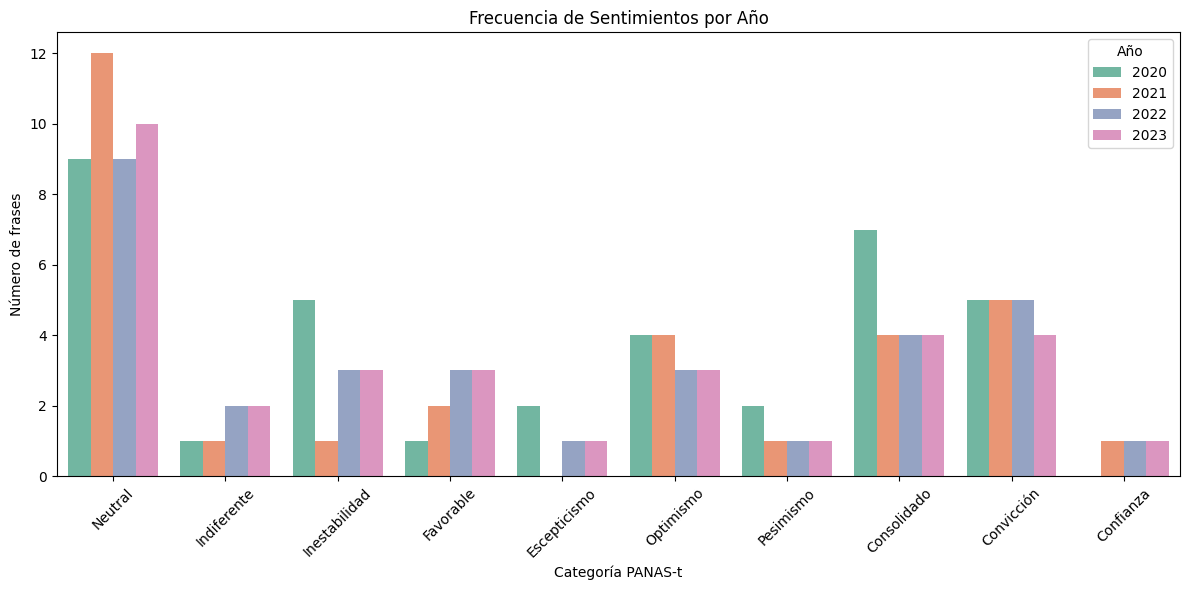

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configura el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Histograma agrupado por categoría y año
sns.countplot(data=df_consolidado, x='Categoría', hue='Año', palette='Set2')

# Estética del gráfico
plt.title('Frecuencia de Sentimientos por Año')
plt.xlabel('Categoría PANAS-t')
plt.ylabel('Número de frases')
plt.xticks(rotation=45)
plt.legend(title='Año')
plt.tight_layout()

# Mostrar el gráfico
plt.show()

Grafico de araña


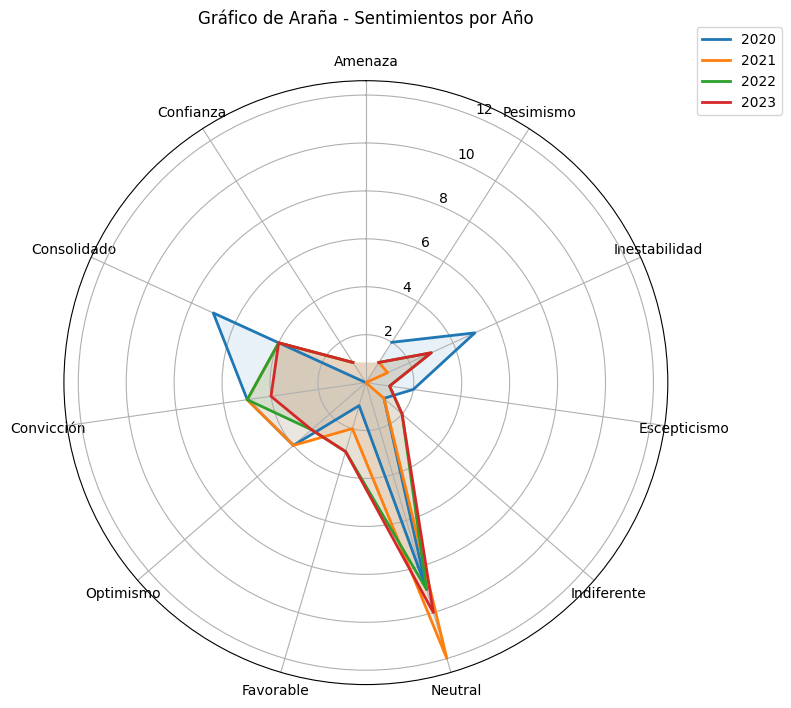

In [15]:
# Crear tabla dinámica: categorías vs años
tabla = df_consolidado.pivot_table(index='Categoría', columns='Año', aggfunc='size', fill_value=0)

# Asegurarse de que el orden de las categorías esté bien (PANAS-t original)
orden_categorias = ['Amenaza', 'Pesimismo', 'Inestabilidad', 'Escepticismo',
                    'Indiferente', 'Neutral', 'Favorable', 'Optimismo',
                    'Convicción', 'Consolidado', 'Confianza']
tabla = tabla.reindex(orden_categorias)

import matplotlib.pyplot as plt
import numpy as np

# Parámetros base
categorias = tabla.index.tolist()
N = len(categorias)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]  # cerrar el gráfico

# Crear el radar plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot por cada año
for año in tabla.columns:
    valores = tabla[año].tolist()
    valores += valores[:1]  # cerrar el gráfico
    ax.plot(angulos, valores, label=str(año), linewidth=2)
    ax.fill(angulos, valores, alpha=0.1)

# Personalización
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angulos[:-1]), categorias)
ax.set_title("Gráfico de Araña - Sentimientos por Año", y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()



In [19]:
df_consolidado['Año'].value_counts()

comentario_positivo = df_consolidado.loc[df_consolidado['Polaridad'].idxmax()]
print(comentario_positivo[['Frase', 'Polaridad', 'Año']])

comentario_negativo = df_consolidado.loc[df_consolidado['Polaridad'].idxmin()]
print(comentario_negativo[['Frase', 'Polaridad', 'Año']])



Frase        Greater importance of trade agreements:** The ...
Polaridad                                               0.9623
Año                                                       2021
Name: 51, dtype: object
Frase        Uncertainty, supply chain disruptions, and wea...
Polaridad                                               -0.802
Año                                                       2021
Name: 42, dtype: object
